In [10]:
from pathlib import Path

import pandas as pd
from plots import plot_a

In [11]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_root = Path("../../logs/foundations/A")

batch_paths = {
    "A0 (baseline)": batch_root / "baseline",
    "A1 (2 yrs)": batch_root / "2years",
    "A2 (4 yrs)": batch_root / "4years",
    "A3 (8 yrs)": batch_root / "8years",
    "A4 (16 yrs)": batch_root / "16years",
}

# find data
data_root = Path("../../tmp/foundation")
target_schedules = pd.read_csv(
    data_root / "experiment_a" / "nts_activities_1years.csv"
)
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    data_root / "experiment_a" / "nts_attributes_1years.csv"
)


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))]
        for k, v in splits
        if k != "unknown"
    }

In [12]:
schedules = {
    n: pd.read_csv(latest(p)[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(latest(p)[1], default=target_attributes)
    for n, p in batch_paths.items()
}
print(schedules.keys())
print(attributes.keys())

Found versions for baseline: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/A/baseline/version_3
Found versions for 2years: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/A/2years/version_3
Found versions for 4years: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/A/4years/version_3
Found versions for 8years: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/A/8years/version_3
Found versions for 16years: ['version_0', 'version_1']. Returning ../../logs/foundations/A/16years/version_1
Found versions for baseline: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/A/baseline/version_3
Loading synthetic attributes from ../../logs/foundations/A/baseline/version_3
Found versions for 2years: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/A/2years/version_3
Loading

In [13]:
training_data_route = Path("../../tmp/foundation/experiment_a")
training_attributes = {
    "baseline": pd.read_csv(training_data_route / "nts_attributes_1years.csv"),
    "2 years": pd.read_csv(training_data_route / "nts_attributes_2years.csv"),
    "4 years": pd.read_csv(training_data_route / "nts_attributes_4years.csv"),
    "8 years": pd.read_csv(training_data_route / "nts_attributes_8years.csv"),
    "16 years": pd.read_csv(training_data_route / "nts_attributes_16years.csv"),
}

counter = {}
# load each and get counts per source
for name, data in training_attributes.items():
    counter[name] = data.year.value_counts()
df = pd.DataFrame(counter)

In [14]:
order = [y for y in range(2009, 2025)][::-1]
df = df.loc[order].fillna(0)
totals = df.sum()
totals_row = pd.DataFrame([totals], index=["Total"])
df = pd.concat([df, totals_row])
print(df.to_latex(float_format="{:.0f}".format))

\begin{tabular}{lrrrrr}
\toprule
 & baseline & 2 years & 4 years & 8 years & 16 years \\
\midrule
2024 & 69826 & 69826 & 69826 & 69826 & 69826 \\
2023 & 0 & 58263 & 58263 & 58263 & 58263 \\
2022 & 0 & 0 & 33185 & 33185 & 33185 \\
2021 & 0 & 0 & 36909 & 36909 & 36909 \\
2020 & 0 & 0 & 0 & 23145 & 23145 \\
2019 & 0 & 0 & 0 & 60446 & 60446 \\
2018 & 0 & 0 & 0 & 59825 & 59825 \\
2017 & 0 & 0 & 0 & 60213 & 60213 \\
2016 & 0 & 0 & 0 & 0 & 66501 \\
2015 & 0 & 0 & 0 & 0 & 66080 \\
2014 & 0 & 0 & 0 & 0 & 69871 \\
2013 & 0 & 0 & 0 & 0 & 68140 \\
2012 & 0 & 0 & 0 & 0 & 81344 \\
2011 & 0 & 0 & 0 & 0 & 76605 \\
2010 & 0 & 0 & 0 & 0 & 80651 \\
2009 & 0 & 0 & 0 & 0 & 85435 \\
Total & 69826 & 128089 & 198183 & 401812 & 996439 \\
\bottomrule
\end{tabular}



In [15]:
def distance_table(batch_path, suffix=""):
    df = pd.read_csv(batch_path / f"domain_distances{suffix}.csv").set_index(
        "domain"
    )
    order = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]
    print(df.loc[order].to_latex(float_format="{:.3f}".format))
    return df.loc[order]


df = distance_table(batch_root, suffix="")

# # conditional
# df = distance_table(batch_root, suffix="_subs")
df

\begin{tabular}{lrrrrrr}
\toprule
 & observed & baseline & 2years & 4years & 8years & 16years \\
domain &  &  &  &  &  &  \\
\midrule
participations & 1.484 & 0.046 & 0.056 & 0.054 & 0.047 & 0.035 \\
transitions & 0.018 & 0.003 & 0.003 & 0.002 & 0.002 & 0.003 \\
timing & 0.444 & 0.022 & 0.020 & 0.018 & 0.016 & 0.015 \\
feasibility & 0.020 & 0.043 & 0.032 & 0.020 & 0.024 & 0.018 \\
creativity & 0.218 & 0.016 & 0.015 & 0.019 & 0.019 & 0.020 \\
\bottomrule
\end{tabular}



,observed,baseline,2years,4years,8years,16years
domain,,,,,,
participations,1.483559,0.046014,0.056453,0.053670,0.046840,0.034975
transitions,0.017727,0.003192,0.003363,0.002491,0.002440,0.002768
timing,0.444189,0.022131,0.020357,0.017680,0.015824,0.014813
feasibility,0.019878,0.042772,0.032050,0.020317,0.023815,0.018003
creativity,0.217920,0.015982,0.015334,0.018791,0.019406,0.019947


In [16]:
df_alt = distance_table(Path("../../logs/foundations/A_alt"), suffix="")
diff = 100 * (df - df_alt) / df_alt
order = ["participations", "transitions", "timing", "feasibility", "creativity"]
print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))
diff

\begin{tabular}{lrrrrrr}
\toprule
 & observed & baseline & 2years & 4years & 8years & 16years \\
domain &  &  &  &  &  &  \\
\midrule
participations & 1.484 & 0.046 & 0.045 & 0.051 & 0.066 & 0.071 \\
transitions & 0.018 & 0.002 & 0.002 & 0.002 & 0.005 & 0.004 \\
timing & 0.444 & 0.019 & 0.018 & 0.016 & 0.022 & 0.021 \\
feasibility & 0.020 & 0.030 & 0.025 & 0.026 & 0.053 & 0.026 \\
creativity & 0.218 & 0.016 & 0.017 & 0.020 & 0.016 & 0.016 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrr}
\toprule
 & observed & baseline & 2years & 4years & 8years & 16years \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.0\% & -0.1\% & 25.2\% & 5.7\% & -28.7\% & -50.7\% \\
transitions & 0.0\% & 28.2\% & 46.0\% & 10.6\% & -47.1\% & -29.2\% \\
timing & 0.0\% & 13.9\% & 15.5\% & 13.2\% & -29.4\% & -28.9\% \\
feasibility & 0.0\% & 43.7\% & 30.5\% & -22.4\% & -55.1\% & -30.4\% \\
creativity & 0.0\% & -2.2\% & -9.9\% & -4.7\% & 23.8\% & 28.1\% \\
\bottomrule
\end{tabular}



<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_890485/1180626207.py:4: SyntaxWarning: invalid escape sequence '\%'
  print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))


,observed,baseline,2years,4years,8years,16years
domain,,,,,,
participations,0.0,-0.080483,25.247016,5.715495,-28.711720,-50.728237
transitions,0.0,28.206845,45.959254,10.602488,-47.064853,-29.221484
timing,0.0,13.925408,15.486780,13.186362,-29.363618,-28.878125
feasibility,0.0,43.656669,30.480547,-22.400119,-55.054375,-30.434284
creativity,0.0,-2.174272,-9.935706,-4.653358,23.805548,28.134088


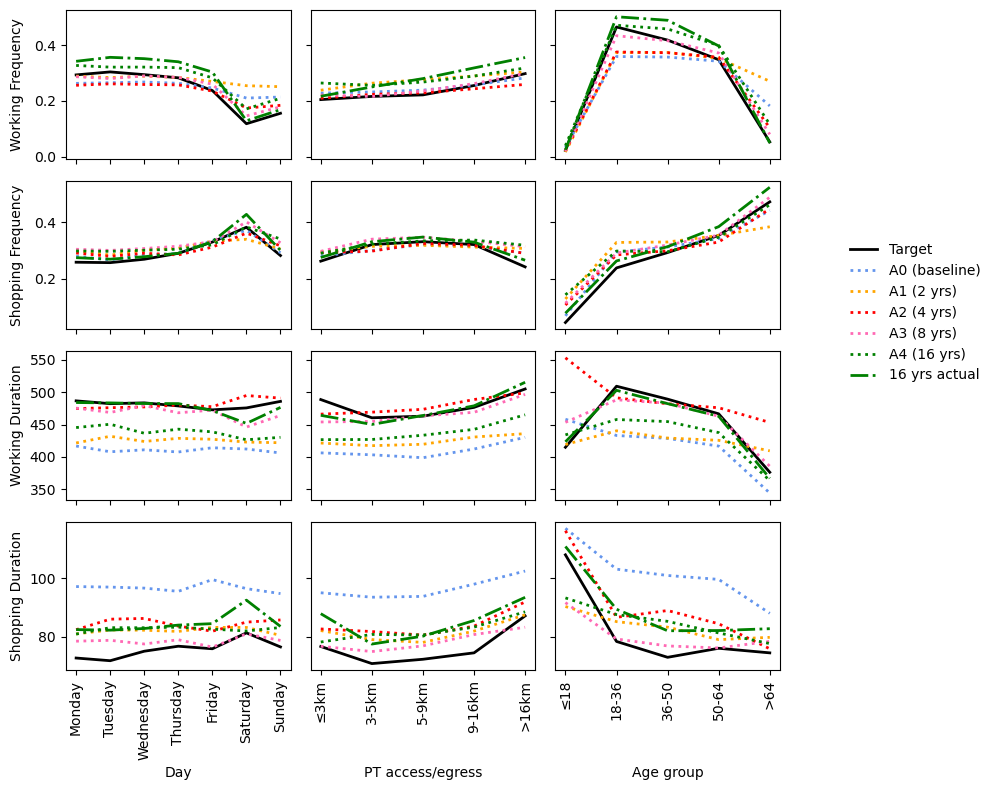

In [17]:
schedules["16 yrs actual"] = pd.read_csv(
    training_data_route / "nts_activities_16years.csv"
)
attributes["16 yrs actual"] = training_attributes["16 years"]

_ = plot_a(schedules, attributes, target_schedules, target_attributes)

In [18]:
# training_schedules = {
#     "baseline": pd.read_csv(training_data_route / "nts_activities_1years.csv"),
#     "2 years": pd.read_csv(training_data_route / "nts_activities_2years.csv"),
#     "4 years": pd.read_csv(training_data_route / "nts_activities_4years.csv"),
#     "8 years": pd.read_csv(training_data_route / "nts_activities_8years.csv"),
#     "16 years": pd.read_csv(training_data_route / "nts_activities_16years.csv"),
# }

# _ = plot_a(
#     training_schedules, training_attributes, target_schedules, target_attributes
# )